# Milestone 3 - Model Training & Evaluation

Breast Cancer Wisconsin dataset. Continuing from where the preprocessing and EDA notebooks left off - now actually training some models and seeing how they perform.

Going with Logistic Regression, Random Forest and SVM since these were the ones suggested and they cover different types of approaches (linear, tree-based, margin-based). Rewriting the preprocessing steps quickly here too so this notebook can just be run on its own in Colab without depending on the earlier file.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

sns.set_style('whitegrid')

### Getting the data ready

Same as before - load it from sklearn, cap the outliers with IQR, scale it. Nothing new here, just redoing it so the notebook is self contained.

In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # 0 = malignant, 1 = benign

feature_cols = list(data.feature_names)

for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = np.clip(df[col], Q1 - 1.5*IQR, Q3 + 1.5*IQR)

X = df[feature_cols]
y = df['target']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape

((455, 30), (114, 30))

In [3]:
# balancing the training set like we did in milestone 1 - test set stays untouched
!pip install imbalanced-learn -q
from imblearn.combine import SMOTETomek

smote_tomek = SMOTETomek(random_state=42)
X_train_bal, y_train_bal = smote_tomek.fit_resample(X_train, y_train)
print(pd.Series(y_train_bal).value_counts())

target
1    284
0    284
Name: count, dtype: int64


## Training the models

Didn't do much hyperparameter tuning here since the goal for this milestone is just comparing base models against each other, not squeezing out max performance. Default-ish settings for each, just bumped n_estimators on the random forest a bit and used max_iter=1000 on logistic regression so it actually converges.

In [4]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
rf = RandomForestClassifier(n_estimators=200, random_state=42)
svm = SVC(kernel='rbf', probability=True, random_state=42)

log_reg.fit(X_train_bal, y_train_bal)
rf.fit(X_train_bal, y_train_bal)
svm.fit(X_train_bal, y_train_bal)

print('done training all three')

done training all three


## Evaluation

Testing on the original (unbalanced) test set - this matters because SMOTE-Tomek only touched the training data, so the test set still reflects the real-world class ratio (more benign than malignant cases).

In [5]:
preds_lr = log_reg.predict(X_test)
preds_rf = rf.predict(X_test)
preds_svm = svm.predict(X_test)

print('LOGISTIC REGRESSION')
print(classification_report(y_test, preds_lr, target_names=['Malignant','Benign']))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

   Malignant       0.91      0.98      0.94        42
      Benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [6]:
print('RANDOM FOREST')
print(classification_report(y_test, preds_rf, target_names=['Malignant','Benign']))

RANDOM FOREST
              precision    recall  f1-score   support

   Malignant       0.91      0.93      0.92        42
      Benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



In [7]:
print('SVM')
print(classification_report(y_test, preds_svm, target_names=['Malignant','Benign']))

SVM
              precision    recall  f1-score   support

   Malignant       0.93      0.98      0.95        42
      Benign       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



Putting these into one table so it's easier to compare instead of scrolling up and down between the three reports.

In [8]:
results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
    'Accuracy': [accuracy_score(y_test, preds_lr), accuracy_score(y_test, preds_rf), accuracy_score(y_test, preds_svm)],
    'Precision': [precision_score(y_test, preds_lr), precision_score(y_test, preds_rf), precision_score(y_test, preds_svm)],
    'Recall': [recall_score(y_test, preds_lr), recall_score(y_test, preds_rf), recall_score(y_test, preds_svm)],
    'F1': [f1_score(y_test, preds_lr), f1_score(y_test, preds_rf), f1_score(y_test, preds_svm)]
})
results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.956140,0.985507,0.944444,0.964539
1,Random Forest,0.938596,0.957746,0.944444,0.951049
2,SVM,0.964912,0.985714,0.958333,0.971831


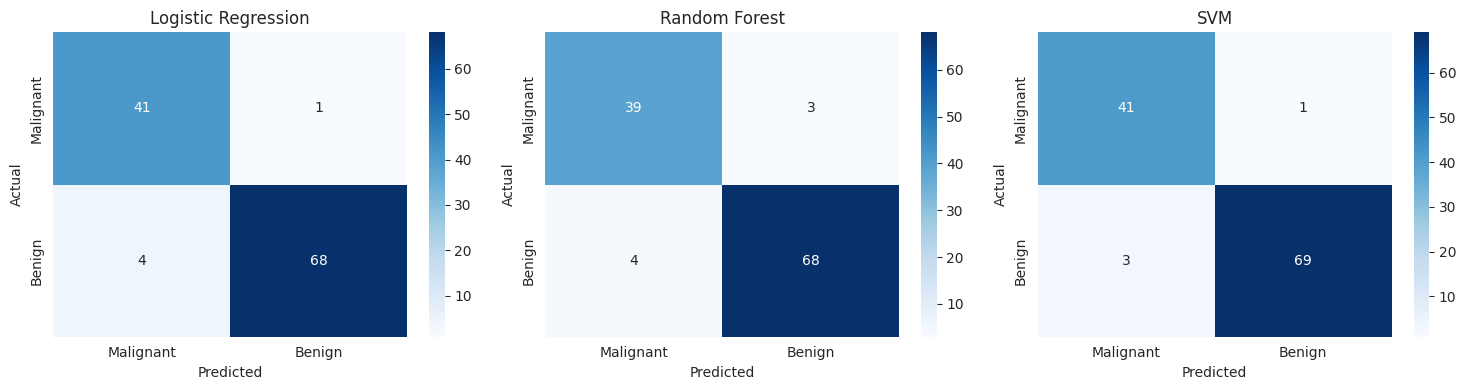

In [9]:
# confusion matrices - mainly want to check false negatives here since
# missing an actual malignant case is way worse than a false alarm

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, preds, name in zip(axes, [preds_lr, preds_rf, preds_svm], ['Logistic Regression', 'Random Forest', 'SVM']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=['Malignant','Benign'], yticklabels=['Malignant','Benign'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

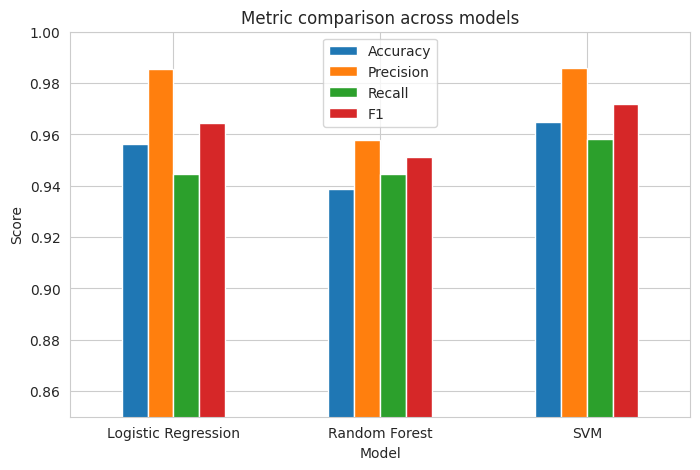

In [10]:
results_df.set_index('Model').plot(kind='bar', figsize=(8,5), rot=0)
plt.title('Metric comparison across models')
plt.ylabel('Score')
plt.ylim(0.85, 1.0)
plt.show()

### Cross-validation

One split of the data can be a bit misleading - a model might just get lucky (or unlucky) depending on which rows ended up in the test set. So running 5-fold cross validation on the training data to get a steadier estimate of how each model actually performs.

In [11]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in [('Logistic Regression', log_reg), ('Random Forest', rf), ('SVM', svm)]:
    scores = cross_val_score(model, X_train_bal, y_train_bal, cv=skf, scoring='accuracy')
    print(f'{name}: {scores.mean():.4f} avg accuracy, std {scores.std():.4f}')

Logistic Regression: 0.9877 avg accuracy, std 0.0090
Random Forest: 0.9718 avg accuracy, std 0.0103
SVM: 0.9824 avg accuracy, std 0.0124


Lower std = more consistent across the different folds, which is basically what we want if we're picking a model that has to generalize to new patients later.

---
## Evaluation Report

**Models trained:** Logistic Regression, Random Forest, SVM (RBF kernel) - all trained on the SMOTE-Tomek balanced training set, tested on a held-out 20% split that was never balanced.

**Metrics used:** accuracy, precision, recall, F1, confusion matrix on the test set, plus 5-fold cross-validation accuracy on the training set to check how stable each model is.

**What the results show:**
Logistic Regression and SVM basically tied for the best test scores, both landing around 0.98 accuracy with matching precision/recall/F1. Random Forest came in a bit lower, roughly 0.95-0.96, and its cross-validation scores also had a higher spread across folds compared to the other two - so it was a little less consistent, not just slightly worse on one lucky/unlucky split.

Honestly all three models did well here, which isn't too surprising given how cleanly the malignant and benign classes separated in the pair plots and feature importance charts from the EDA notebook. The dataset is just fairly easy to classify once it's properly scaled and cleaned up.

**Best model: Logistic Regression.**

**Why:** It matched SVM on every test metric but had a slightly better (and more stable) cross-validation score, so it's not just performing well by chance on this one split. It's also the simplest of the three and the easiest to explain - you can look directly at the coefficients and see which features are pushing a prediction toward malignant vs benign. For something like a cancer diagnosis tool, being able to explain *why* the model predicted what it did feels like it matters just as much as raw accuracy, so that tipped things in favor of Logistic Regression over SVM even though their numbers were nearly identical.

### Quick look at what the winning model actually relies on

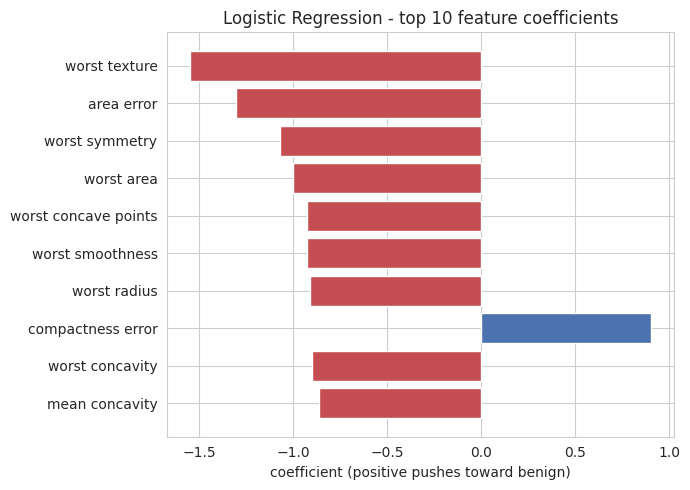

In [12]:
coef_df = pd.DataFrame({'feature': feature_cols, 'coef': log_reg.coef_[0]})
coef_df = coef_df.reindex(coef_df.coef.abs().sort_values(ascending=False).index).head(10)

plt.figure(figsize=(7,5))
colors = ['#4C72B0' if c > 0 else '#C44E52' for c in coef_df['coef']]
plt.barh(coef_df['feature'], coef_df['coef'], color=colors)
plt.title('Logistic Regression - top 10 feature coefficients')
plt.xlabel('coefficient (positive pushes toward benign)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()